<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/Attention_Efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple


In [13]:
class StandardAttention(nn.Module):
    """Standard scaled dot-product attention: O(n²d) time, O(n²) memory."""

    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None):
        B, N, _ = x.shape

        # Project to Q, K, V and reshape to multi-head
        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        # Shapes: (B, H, N, d_head)

        # Compute attention scores — THIS is the O(n²) bottleneck
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B, H, N, N)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)  # (B, H, N, N)
        output = torch.matmul(attn_weights, V)     # (B, H, N, d_head)

        # Reshape and project
        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output), attn_weights


# Quick test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
std_attn = StandardAttention(d_model=256, n_heads=8).to(device)
x = torch.randn(2, 512, 256, device=device)
out, weights = std_attn(x)
print(f'Input:  {x.shape}')
print(f'Output: {out.shape}')
print(f'Attention weights: {weights.shape}  ← This is the n×n matrix')
print(f'Attention matrix entries: {weights.shape[-1] * weights.shape[-2]:,}')

Input:  torch.Size([2, 512, 256])
Output: torch.Size([2, 512, 256])
Attention weights: torch.Size([2, 8, 512, 512])  ← This is the n×n matrix
Attention matrix entries: 262,144


In [14]:
class LinearAttention(nn.Module):
    """Linear attention using ELU feature map.

    Complexity: O(nd²) — linear in sequence length.
    Based on: Katharopoulos et al., 'Transformers are RNNs' (2020)
    """

    def __init__(self, d_model: int, n_heads: int, eps: float = 1e-6):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.eps = eps

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def feature_map(self, x: torch.Tensor) -> torch.Tensor:
        """ELU-based feature map: φ(x) = elu(x) + 1 (ensures non-negative)"""
        return F.elu(x) + 1

    def forward(self, x: torch.Tensor, causal: bool = False):
        B, N, _ = x.shape

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        # Apply feature map
        phi_Q = self.feature_map(Q)  # (B, H, N, d)
        phi_K = self.feature_map(K)  # (B, H, N, d)

        if causal:
            # Causal linear attention via cumulative sums
            # S_i = Σ_{j≤i} φ(K_j)ᵀ V_j  (running state)
            # z_i = Σ_{j≤i} φ(K_j)        (running normalizer)
            output = torch.zeros_like(V)
            S = torch.zeros(B, self.n_heads, self.d_head, self.d_head, device=x.device)
            z = torch.zeros(B, self.n_heads, 1, self.d_head, device=x.device)

            for i in range(N):
                k_i = phi_K[:, :, i:i+1, :]   # (B, H, 1, d)
                v_i = V[:, :, i:i+1, :]         # (B, H, 1, d)
                q_i = phi_Q[:, :, i:i+1, :]     # (B, H, 1, d)

                S = S + torch.matmul(k_i.transpose(-2, -1), v_i)  # (B, H, d, d)
                z = z + k_i                                         # (B, H, 1, d)

                num = torch.matmul(q_i, S)                # (B, H, 1, d)
                den = torch.matmul(q_i, z.transpose(-2, -1)) + self.eps  # (B, H, 1, 1)
                output[:, :, i:i+1, :] = num / den
        else:
            # Non-causal: the efficient trick
            # Instead of φ(Q)φ(K)ᵀ (n×n) → V, compute φ(K)ᵀV (d×d) first
            KV = torch.matmul(phi_K.transpose(-2, -1), V)  # (B, H, d, d) ← KEY!
            Z = phi_K.sum(dim=-2, keepdim=True)             # (B, H, 1, d)

            numerator = torch.matmul(phi_Q, KV)              # (B, H, N, d)
            denominator = torch.matmul(phi_Q, Z.transpose(-2, -1)) + self.eps  # (B, H, N, 1)
            output = numerator / denominator

        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output)


# Test
lin_attn = LinearAttention(d_model=256, n_heads=8).to(device)
out_lin = lin_attn(x)
print(f'Linear attention output: {out_lin.shape}')
print(f'Key insight: No n×n matrix was ever created!')
print(f'Largest intermediate: (B, H, d, d) = ({2}, {8}, {32}, {32}) vs n×n = ({512}, {512})')

Linear attention output: torch.Size([2, 512, 256])
Key insight: No n×n matrix was ever created!
Largest intermediate: (B, H, d, d) = (2, 8, 32, 32) vs n×n = (512, 512)


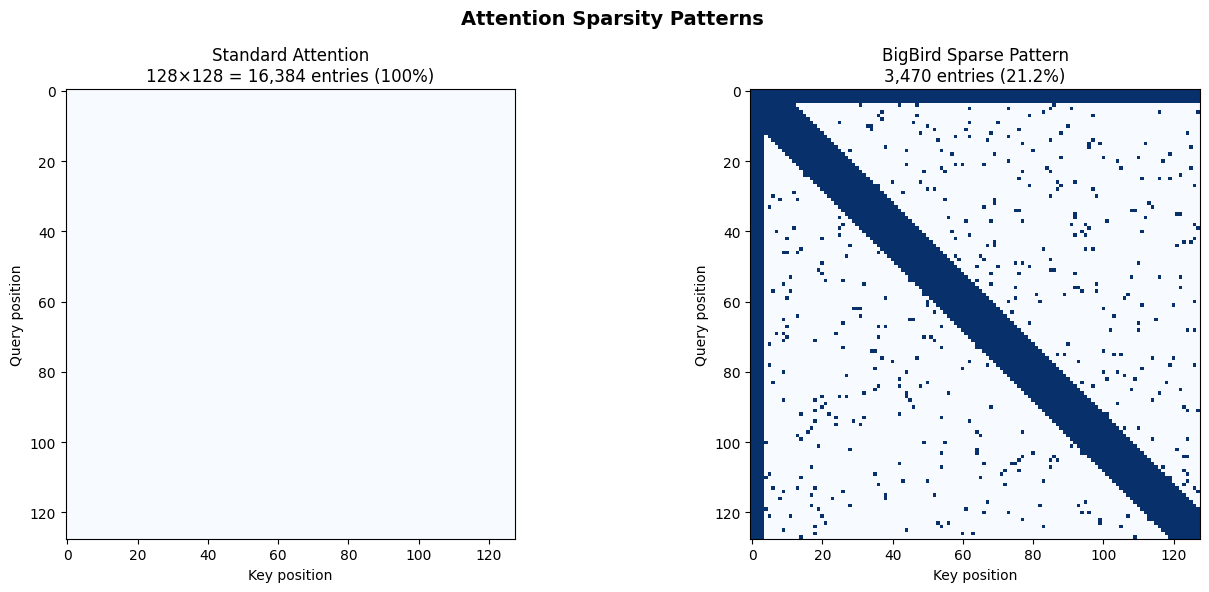


Compression ratio: 4.7× fewer attention computations


In [15]:
class SlidingWindowAttention(nn.Module):
    """Longformer-style sliding window attention: O(n·w).

    Each token attends only to tokens within a fixed window.
    """

    def __init__(self, d_model: int, n_heads: int, window_size: int = 64):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.window_size = window_size

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor):
        B, N, _ = x.shape
        w = self.window_size
        half_w = w // 2

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        output = torch.zeros_like(V)

        for i in range(N):
            # Define window boundaries
            start = max(0, i - half_w)
            end = min(N, i + half_w + 1)

            q_i = Q[:, :, i:i+1, :]       # (B, H, 1, d)
            k_win = K[:, :, start:end, :]  # (B, H, w, d)
            v_win = V[:, :, start:end, :]  # (B, H, w, d)

            scores = torch.matmul(q_i, k_win.transpose(-2, -1)) / math.sqrt(self.d_head)
            attn = F.softmax(scores, dim=-1)
            output[:, :, i:i+1, :] = torch.matmul(attn, v_win)

        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output)


class BigBirdStyleAttention(nn.Module):
    """Simplified BigBird: local window + global tokens + random connections.

    Zaheer et al. proved this combination is a universal approximator.
    """

    def __init__(self, d_model: int, n_heads: int, window_size: int = 64,
                 n_global: int = 4, n_random: int = 8):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.window_size = window_size
        self.n_global = n_global
        self.n_random = n_random

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def _build_attention_mask(self, N: int, device):
        """Build sparse attention pattern: local + global + random."""
        mask = torch.zeros(N, N, dtype=torch.bool, device=device)
        half_w = self.window_size // 2

        for i in range(N):
            # Local window
            start = max(0, i - half_w)
            end = min(N, i + half_w + 1)
            mask[i, start:end] = True

            # Global tokens (first n_global positions attend/are attended to by all)
            mask[i, :self.n_global] = True
            mask[:self.n_global, i] = True

            # Random connections
            rand_idx = torch.randperm(N, device=device)[:self.n_random]
            mask[i, rand_idx] = True

        return mask

    def forward(self, x: torch.Tensor):
        B, N, _ = x.shape

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        # Build sparse mask
        attn_mask = self._build_attention_mask(N, x.device)

        # Full attention with masking (in practice, use block-sparse kernels)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores.masked_fill(~attn_mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        attn = F.softmax(scores, dim=-1)

        output = torch.matmul(attn, V)
        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output), attn_mask


# Test and visualize
N_test = 128  # Small for visualization
x_test = torch.randn(1, N_test, 256, device=device)

bigbird = BigBirdStyleAttention(d_model=256, n_heads=8, window_size=16,
                                 n_global=4, n_random=4).to(device)
out_bb, mask_bb = bigbird(x_test)

# Visualize sparsity pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full attention pattern (all ones)
axes[0].imshow(torch.ones(N_test, N_test).cpu(), cmap='Blues', aspect='equal')
axes[0].set_title(f'Standard Attention\n{N_test}×{N_test} = {N_test**2:,} entries (100%)', fontsize=12)
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')

# Sparse pattern
sparsity = mask_bb.float().mean().item()
axes[1].imshow(mask_bb.cpu().float(), cmap='Blues', aspect='equal')
axes[1].set_title(f'BigBird Sparse Pattern\n{mask_bb.sum().item():,} entries ({sparsity*100:.1f}%)', fontsize=12)
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')

plt.suptitle('Attention Sparsity Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nCompression ratio: {1/sparsity:.1f}× fewer attention computations')

In [16]:
class LinformerAttention(nn.Module):
    """Linformer: Low-rank projected attention O(nk).

    Wang et al., 2020: Projects K, V to fixed lower dimension.
    """

    def __init__(self, d_model: int, n_heads: int, seq_len: int, k: int = 64):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.k = k  # Projected dimension

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        # Learned projections: (k × n) — project sequence length
        self.E = nn.Parameter(torch.randn(k, seq_len) / math.sqrt(seq_len))
        self.F = nn.Parameter(torch.randn(k, seq_len) / math.sqrt(seq_len))

    def forward(self, x: torch.Tensor):
        B, N, _ = x.shape

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        # Project K: (B, H, N, d) → (B, H, k, d) via E(k,N) @ K(N,d)
        K_proj = torch.matmul(self.E[:, :N].unsqueeze(0).unsqueeze(0), K)  # (B, H, k, d)
        V_proj = torch.matmul(self.F[:, :N].unsqueeze(0).unsqueeze(0), V)  # (B, H, k, d)

        # Now attention is Q(N,d) @ K_proj(d,k) = (N,k) instead of (N,N)!
        scores = torch.matmul(Q, K_proj.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B, H, N, k)
        attn = F.softmax(scores, dim=-1)
        output = torch.matmul(attn, V_proj)  # (B, H, N, d)

        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output)


# Test
linformer = LinformerAttention(d_model=256, n_heads=8, seq_len=512, k=64).to(device)
out_lf = linformer(x)
print(f'Linformer output: {out_lf.shape}')
print(f'Attention matrix: (N, k) = (512, 64) instead of (512, 512)')
print(f'Reduction: {512*512 / (512*64):.1f}× fewer attention entries')

Linformer output: torch.Size([2, 512, 256])
Attention matrix: (N, k) = (512, 64) instead of (512, 512)
Reduction: 8.0× fewer attention entries


In [17]:
class GroupedQueryAttention(nn.Module):
    """Grouped-Query Attention (GQA).

    - g = n_heads → Standard MHA
    - g = 1      → Multi-Query Attention (MQA)
    - 1 < g < h  → Grouped-Query Attention
    """

    def __init__(self, d_model: int, n_heads: int, n_kv_groups: int = 1):
        super().__init__()
        assert n_heads % n_kv_groups == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.n_kv_groups = n_kv_groups
        self.heads_per_group = n_heads // n_kv_groups
        self.d_head = d_model // n_heads

        # Q has full heads, K/V only have n_kv_groups heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, n_kv_groups * self.d_head)
        self.W_v = nn.Linear(d_model, n_kv_groups * self.d_head)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor):
        B, N, _ = x.shape

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, N, self.n_kv_groups, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, N, self.n_kv_groups, self.d_head).transpose(1, 2)

        # Repeat K, V for each head in the group
        K = K.repeat_interleave(self.heads_per_group, dim=1)  # (B, H, N, d)
        V = V.repeat_interleave(self.heads_per_group, dim=1)

        # Standard attention from here
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = F.softmax(scores, dim=-1)
        output = torch.matmul(attn, V)

        output = output.transpose(1, 2).contiguous().view(B, N, self.d_model)
        return self.W_o(output)


# Compare KV cache sizes
print('KV Cache Comparison (seq_len=2048, d_model=256, 8 heads):')
print('=' * 60)

d_head = 32
seq_len_cache = 2048

for name, g in [('MHA (8 groups)', 8), ('GQA (4 groups)', 4),
                ('GQA (2 groups)', 2), ('MQA (1 group)', 1)]:
    cache_size = g * 2 * d_head * seq_len_cache * 4  # float32 bytes
    model = GroupedQueryAttention(d_model=256, n_heads=8, n_kv_groups=g).to(device)
    kv_params = sum(p.numel() for n, p in model.named_parameters() if 'W_k' in n or 'W_v' in n)
    print(f'{name:20s} | KV cache: {cache_size/1024:.1f} KB | KV params: {kv_params:,}')

# Test all variants
for g in [8, 4, 2, 1]:
    gqa = GroupedQueryAttention(d_model=256, n_heads=8, n_kv_groups=g).to(device)
    out = gqa(x)
    assert out.shape == (2, 512, 256), f'Shape mismatch for g={g}'

KV Cache Comparison (seq_len=2048, d_model=256, 8 heads):
MHA (8 groups)       | KV cache: 4096.0 KB | KV params: 131,584
GQA (4 groups)       | KV cache: 2048.0 KB | KV params: 65,792
GQA (2 groups)       | KV cache: 1024.0 KB | KV params: 32,896
MQA (1 group)        | KV cache: 512.0 KB | KV params: 16,448


In [18]:
def benchmark_attention(module, x, name, n_warmup=3, n_runs=10):
    """Benchmark an attention module for speed and memory."""
    module.eval()

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            try:
                out = module(x)
                if isinstance(out, tuple):
                    out = out[0]
            except RuntimeError as e:
                return {'name': name, 'time_ms': float('inf'), 'memory_mb': float('inf'), 'error': str(e)}

    # Memory tracking
    if x.is_cuda:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    # Timing
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            out = module(x)
            if isinstance(out, tuple):
                out = out[0]

    if x.is_cuda:
        torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / n_runs * 1000  # ms

    peak_mem = torch.cuda.max_memory_allocated() / 1e6 if x.is_cuda else 0

    return {'name': name, 'time_ms': elapsed, 'memory_mb': peak_mem}


# Run benchmarks across sequence lengths
d_model = 256
n_heads = 8
batch_size = 2
seq_lengths = [128, 256, 512, 1024, 2048]

results = {}

for N in seq_lengths:
    print(f'\nBenchmarking seq_len={N}...')
    x_bench = torch.randn(batch_size, N, d_model, device=device)

    modules = {
        'Standard O(n²)': StandardAttention(d_model, n_heads).to(device),
        'Linear O(nd²)': LinearAttention(d_model, n_heads).to(device),
        'Linformer O(nk)': LinformerAttention(d_model, n_heads, seq_len=N, k=64).to(device),
        'GQA (4 groups)': GroupedQueryAttention(d_model, n_heads, n_kv_groups=4).to(device),
        'MQA (1 group)': GroupedQueryAttention(d_model, n_heads, n_kv_groups=1).to(device),
    }

    for mname, module in modules.items():
        result = benchmark_attention(module, x_bench, mname)
        results.setdefault(mname, {'times': [], 'mems': []})
        results[mname]['times'].append(result['time_ms'])
        results[mname]['mems'].append(result['memory_mb'])
        print(f'  {mname:25s} | {result["time_ms"]:8.2f} ms | {result["memory_mb"]:8.1f} MB')

print('\nDone!')


Benchmarking seq_len=128...
  Standard O(n²)            |     7.22 ms |      0.0 MB
  Linear O(nd²)             |     7.30 ms |      0.0 MB
  Linformer O(nk)           |     6.88 ms |      0.0 MB
  GQA (4 groups)            |     6.35 ms |      0.0 MB
  MQA (1 group)             |     5.83 ms |      0.0 MB

Benchmarking seq_len=256...
  Standard O(n²)            |    18.44 ms |      0.0 MB
  Linear O(nd²)             |    13.12 ms |      0.0 MB
  Linformer O(nk)           |    13.02 ms |      0.0 MB
  GQA (4 groups)            |    15.99 ms |      0.0 MB
  MQA (1 group)             |    14.17 ms |      0.0 MB

Benchmarking seq_len=512...
  Standard O(n²)            |    58.20 ms |      0.0 MB
  Linear O(nd²)             |    23.50 ms |      0.0 MB
  Linformer O(nk)           |    14.83 ms |      0.0 MB
  GQA (4 groups)            |    40.31 ms |      0.0 MB
  MQA (1 group)             |    35.58 ms |      0.0 MB

Benchmarking seq_len=1024...
  Standard O(n²)            |   210.73 ms |

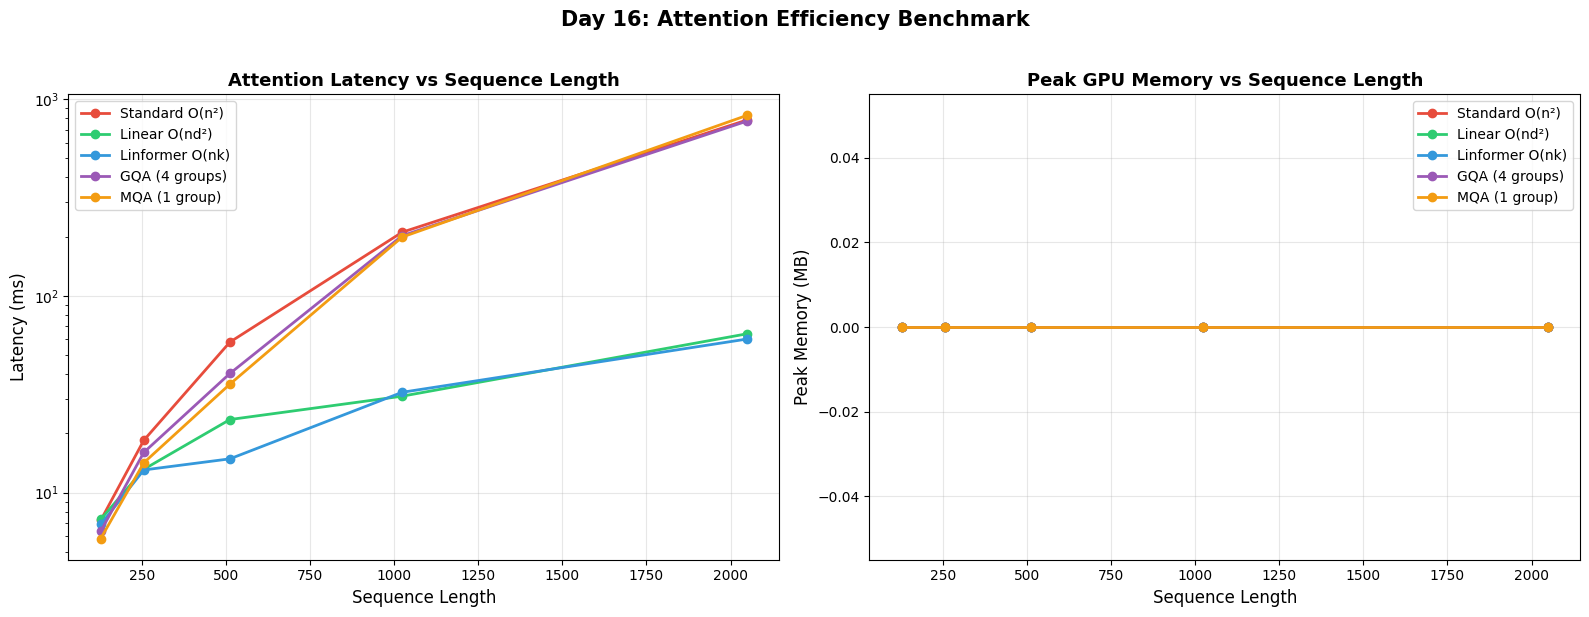

In [19]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

for idx, (name, data) in enumerate(results.items()):
    axes[0].plot(seq_lengths, data['times'], 'o-', label=name,
                color=colors[idx], linewidth=2, markersize=6)
    axes[1].plot(seq_lengths, data['mems'], 'o-', label=name,
                color=colors[idx], linewidth=2, markersize=6)

axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Attention Latency vs Sequence Length', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Peak Memory (MB)', fontsize=12)
axes[1].set_title('Peak GPU Memory vs Sequence Length', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Day 16: Attention Efficiency Benchmark', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
print('Scaling Ratios (time[2n] / time[n]):')
print('=' * 70)
print(f'{"Method":25s} | ', end='')
for i in range(1, len(seq_lengths)):
    print(f'{seq_lengths[i-1]}→{seq_lengths[i]:>5} | ', end='')
print()
print('-' * 70)

for name, data in results.items():
    print(f'{name:25s} | ', end='')
    for i in range(1, len(data['times'])):
        if data['times'][i-1] > 0:
            ratio = data['times'][i] / data['times'][i-1]
            print(f'{ratio:9.2f}× | ', end='')
        else:
            print(f'{"N/A":>9s} | ', end='')
    print()

print()
print('Expected scaling ratios (doubling seq length):')
print('  O(n²):  ~4.0×')
print('  O(n):   ~2.0×')
print('  O(n√n): ~2.8×')

Scaling Ratios (time[2n] / time[n]):
Method                    | 128→  256 | 256→  512 | 512→ 1024 | 1024→ 2048 | 
----------------------------------------------------------------------
Standard O(n²)            |      2.55× |      3.16× |      3.62× |      3.72× | 
Linear O(nd²)             |      1.80× |      1.79× |      1.31× |      2.07× | 
Linformer O(nk)           |      1.89× |      1.14× |      2.18× |      1.86× | 
GQA (4 groups)            |      2.52× |      2.52× |      5.02× |      3.82× | 
MQA (1 group)             |      2.43× |      2.51× |      5.60× |      4.15× | 

Expected scaling ratios (doubling seq length):
  O(n²):  ~4.0×
  O(n):   ~2.0×
  O(n√n): ~2.8×


In [21]:
class SearchableAttentionLayer(nn.Module):
    """Attention layer with searchable mechanism type.

    For use in NAS: the attention type is an architectural decision
    that can be selected per layer by the search algorithm.
    """

    ATTENTION_TYPES = ['standard', 'linear', 'linformer', 'gqa4', 'mqa']

    def __init__(self, d_model: int, n_heads: int, seq_len: int,
                 attn_type: str = 'standard'):
        super().__init__()
        self.attn_type = attn_type

        if attn_type == 'standard':
            self.attn = StandardAttention(d_model, n_heads)
        elif attn_type == 'linear':
            self.attn = LinearAttention(d_model, n_heads)
        elif attn_type == 'linformer':
            self.attn = LinformerAttention(d_model, n_heads, seq_len, k=64)
        elif attn_type == 'gqa4':
            self.attn = GroupedQueryAttention(d_model, n_heads, n_kv_groups=4)
        elif attn_type == 'mqa':
            self.attn = GroupedQueryAttention(d_model, n_heads, n_kv_groups=1)
        else:
            raise ValueError(f'Unknown attention type: {attn_type}')

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor):
        residual = x
        x = self.norm(x)
        out = self.attn(x)
        if isinstance(out, tuple):
            out = out[0]
        return residual + out

    def get_cost_metrics(self, seq_len: int, d_model: int) -> dict:
        """Estimated costs for hardware-aware NAS reward."""
        d = d_model // 8  # d_head
        n = seq_len

        costs = {
            'standard': {'flops': n*n*d, 'memory': n*n, 'label': 'O(n²d)'},
            'linear':   {'flops': n*d*d, 'memory': d*d, 'label': 'O(nd²)'},
            'linformer': {'flops': n*64*d, 'memory': n*64, 'label': 'O(nk)'},
            'gqa4':     {'flops': n*n*d, 'memory': n*n, 'label': 'O(n²d), 4×KV saving'},
            'mqa':      {'flops': n*n*d, 'memory': n*n, 'label': 'O(n²d), h×KV saving'},
        }
        return costs[self.attn_type]


class HeterogeneousAttentionTransformer(nn.Module):
    """Transformer where each layer can use a different attention mechanism.

    This is the architecture that a NAS agent would search over.
    """

    def __init__(self, d_model: int, n_heads: int, n_layers: int,
                 seq_len: int, attn_types: list):
        super().__init__()
        assert len(attn_types) == n_layers

        self.layers = nn.ModuleList([
            SearchableAttentionLayer(d_model, n_heads, seq_len, atype)
            for atype in attn_types
        ])

    def forward(self, x: torch.Tensor):
        for layer in self.layers:
            x = layer(x)
        return x


# Example: NAS-discovered heterogeneous architecture
# Bottom layers use cheap attention, middle layers use standard, top uses linear
arch_config = ['linear', 'linear', 'linformer', 'standard', 'gqa4', 'linear']

model = HeterogeneousAttentionTransformer(
    d_model=256, n_heads=8, n_layers=6, seq_len=512,
    attn_types=arch_config
).to(device)

out = model(x)
total_params = sum(p.numel() for p in model.parameters())

print(f'Heterogeneous Attention Transformer')
print(f'Architecture: {arch_config}')
print(f'Total parameters: {total_params:,}')
print(f'Output shape: {out.shape}')
print()
print('Per-layer cost profile:')
for i, layer in enumerate(model.layers):
    cost = layer.get_cost_metrics(512, 256)
    print(f'  Layer {i}: {layer.attn_type:12s} → {cost["label"]}')

Heterogeneous Attention Transformer
Architecture: ['linear', 'linear', 'linformer', 'standard', 'gqa4', 'linear']
Total parameters: 1,581,824
Output shape: torch.Size([2, 512, 256])

Per-layer cost profile:
  Layer 0: linear       → O(nd²)
  Layer 1: linear       → O(nd²)
  Layer 2: linformer    → O(nk)
  Layer 3: standard     → O(n²d)
  Layer 4: gqa4         → O(n²d), 4×KV saving
  Layer 5: linear       → O(nd²)
